In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binomtest

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_parquet(
    DATA_DIR / "customer_retention_dataset.parquet"
)

print(customers.shape)
display(customers.head())
display(customers.dtypes)

(5281, 18)


,customer_id,first_order_id,first_order_date,first_order_value,first_order_quantity,first_order_unique_products,first_order_product_lines,first_order_average_item_price,first_order_country,first_order_weekday,first_order_month,first_order_hour,first_order_is_weekend,second_order_date,days_to_second_order,available_followup_days,has_full_90d_followup,repeat_within_90d
0,12346,491725,2009-12-14 08:34:00,45.00,10,1,1,4.500000,United Kingdom,Monday,12,8,False,2009-12-14 11:00:00,0.101389,725.177778,True,1
1,12347,529924,2010-10-31 14:20:00,611.53,509,40,40,1.201434,Iceland,Sunday,10,14,True,2010-12-07 14:57:00,37.025694,403.937500,True,1
2,12348,524140,2010-09-27 14:59:00,222.16,373,20,20,0.595603,Finland,Monday,9,14,False,2010-12-16 19:09:00,80.173611,437.910417,True,1
3,12349,506394,2010-04-29 13:20:00,1068.52,473,46,46,2.259027,Italy,Thursday,4,13,False,2010-05-18 09:57:00,18.859028,588.979167,True,1
4,12350,543037,2011-02-02 16:01:00,334.40,197,17,17,1.697462,Norway,Wednesday,2,16,False,NaT,NaN,309.867361,True,0


customer_id                       string[python]
first_order_id                    string[python]
first_order_date                  datetime64[ns]
first_order_value                        float64
first_order_quantity                       int64
first_order_unique_products                int64
first_order_product_lines                  int64
first_order_average_item_price           float64
first_order_country               string[python]
first_order_weekday                       object
first_order_month                          int32
first_order_hour                           int32
first_order_is_weekend                      bool
second_order_date                 datetime64[ns]
days_to_second_order                     float64
available_followup_days                  float64
has_full_90d_followup                       bool
repeat_within_90d                          int32
dtype: object

In [19]:
assert customers["customer_id"].is_unique
assert customers["repeat_within_90d"].isin([0, 1]).all()
assert customers["available_followup_days"].ge(90).all()

In [20]:
n_customers = len(customers)
n_repeat = customers["repeat_within_90d"].sum()
repeat_rate = customers["repeat_within_90d"].mean()

confidence_interval = binomtest(
    k=n_repeat,
    n=n_customers
).proportion_ci(
    confidence_level=0.95,
    method="wilson"
)

print(f"Eligible customers: {n_customers:,}")
print(f"Repeat customers: {n_repeat:,}")
print(f"90-day repeat rate: {repeat_rate:.2%}")
print(
    f"95% CI: "
    f"[{confidence_interval.low:.2%}, "
    f"{confidence_interval.high:.2%}]"
)

Eligible customers: 5,281
Repeat customers: 2,484
90-day repeat rate: 47.04%
95% CI: [45.69%, 48.38%]


The estimated 90-day repeat rate among eligible identifiable customers is 46.87%, with a 95% confidence interval of approximately [45.69%, 48.38%].

In [21]:
feature_columns = [
    "first_order_value",
    "first_order_quantity",
    "first_order_unique_products",
    "first_order_product_lines",
    "first_order_average_item_price",
]

customers[feature_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
first_order_value,5281.0,412.016877,756.957581,1.3000,21.000000,72.900000,166.240000,293.530000,446.620000,1056.630000,2330.136,33167.8
first_order_quantity,5281.0,259.459572,1294.584843,1.0000,1.000000,21.000000,79.000000,150.000000,277.000000,675.000000,1560.200,87167.0
first_order_unique_products,5281.0,23.722590,22.457774,1.0000,1.000000,2.000000,9.000000,18.000000,31.000000,65.000000,111.000,250.0
first_order_product_lines,5281.0,24.078394,23.105774,1.0000,1.000000,2.000000,9.000000,18.000000,31.000000,66.000000,115.000,251.0
first_order_average_item_price,5281.0,7.788863,182.401885,0.1363,0.457813,0.819945,1.405436,1.895838,2.611682,5.269048,22.255,10953.5


In [22]:
distribution_summary = customers[feature_columns].agg(
    ["mean", "median", "std", "min", "max"]
).T

distribution_summary

,mean,median,std,min,max
first_order_value,412.016877,293.530000,756.957581,1.3000,33167.8
first_order_quantity,259.459572,150.000000,1294.584843,1.0000,87167.0
first_order_unique_products,23.722590,18.000000,22.457774,1.0000,250.0
first_order_product_lines,24.078394,18.000000,23.105774,1.0000,251.0
first_order_average_item_price,7.788863,1.895838,182.401885,0.1363,10953.5


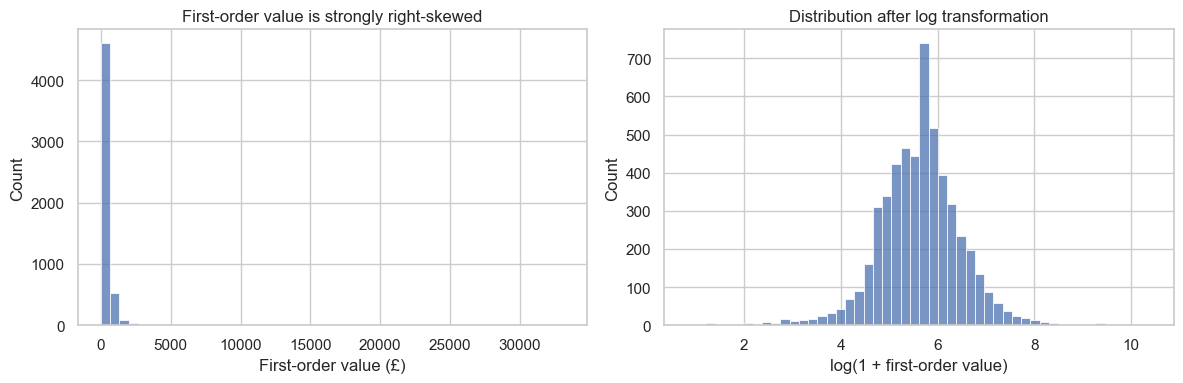

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=customers,
    x="first_order_value",
    bins=50,
    ax=axes[0]
)

axes[0].set_title("First-order value is strongly right-skewed")
axes[0].set_xlabel("First-order value (£)")

sns.histplot(
    np.log1p(customers["first_order_value"]),
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Distribution after log transformation")
axes[1].set_xlabel("log(1 + first-order value)")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "first_order_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
returned = customers.loc[
    customers["second_order_date"].notna()
].copy()

returned["days_to_second_order"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

count    4023.000000
mean      101.806445
std       114.601938
min         0.000694
10%         4.168194
25%        21.852083
50%        60.851389
75%       138.041319
90%       268.691389
max       714.152083
Name: days_to_second_order, dtype: float64

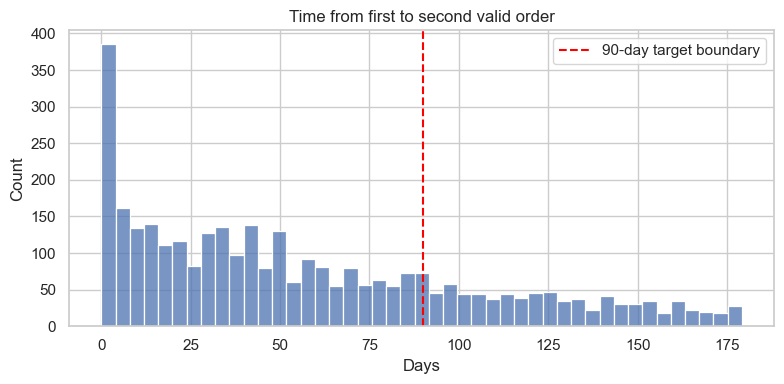

In [25]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=returned[
        returned["days_to_second_order"].between(0, 180)
    ],
    x="days_to_second_order",
    bins=45
)

plt.axvline(
    90,
    color="red",
    linestyle="--",
    label="90-day target boundary"
)

plt.title("Time from first to second valid order")
plt.xlabel("Days")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "days_to_second_order.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
def segment_repeat_summary(data, segment):
    summary = (
        data.groupby(segment, observed=True)
        .agg(
            customers=("customer_id", "size"),
            repeat_customers=("repeat_within_90d", "sum"),
            repeat_rate=("repeat_within_90d", "mean"),
        )
        .reset_index()
    )

    intervals = summary.apply(
        lambda row: binomtest(
            int(row["repeat_customers"]),
            int(row["customers"])
        ).proportion_ci(
            confidence_level=0.95,
            method="wilson"
        ),
        axis=1
    )

    summary["ci_low"] = [interval.low for interval in intervals]
    summary["ci_high"] = [interval.high for interval in intervals]

    return summary

In [27]:
customers["first_order_value_band"] = pd.qcut(
    customers["first_order_value"],
    q=5,
    duplicates="drop"
)

value_summary = segment_repeat_summary(
    customers,
    "first_order_value_band"
)

value_summary

,first_order_value_band,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,"(1.2990000000000002, 147.27]",1057,376,0.355724,0.327433,0.385059
1,"(147.27, 233.4]",1056,435,0.411932,0.382618,0.441884
2,"(233.4, 327.95]",1056,513,0.485795,0.455757,0.515937
3,"(327.95, 518.35]",1056,533,0.504735,0.474617,0.534819
4,"(518.35, 33167.8]",1056,627,0.593750,0.563840,0.622980


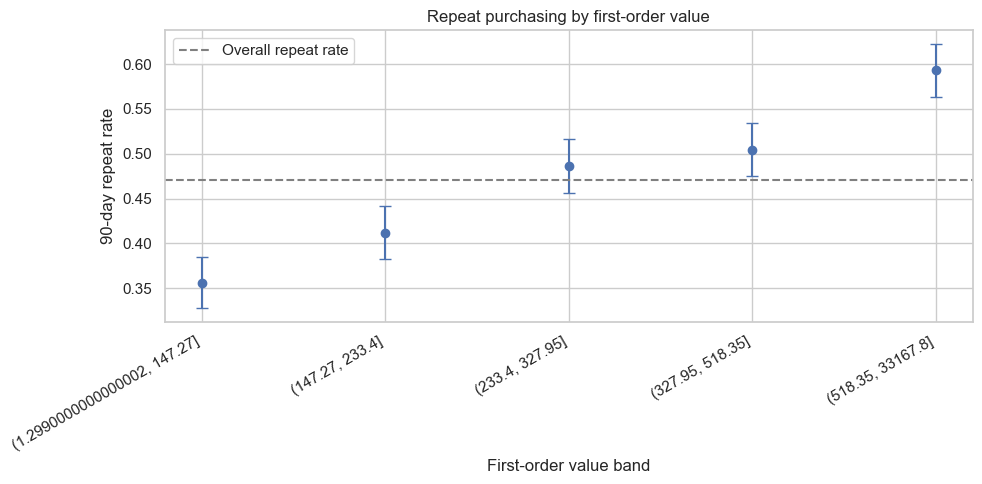

In [28]:
plt.figure(figsize=(10, 5))

x = np.arange(len(value_summary))

plt.errorbar(
    x=x,
    y=value_summary["repeat_rate"],
    yerr=[
        value_summary["repeat_rate"] - value_summary["ci_low"],
        value_summary["ci_high"] - value_summary["repeat_rate"],
    ],
    fmt="o",
    capsize=4
)

plt.xticks(
    x,
    value_summary["first_order_value_band"].astype(str),
    rotation=30,
    ha="right"
)

plt.axhline(
    repeat_rate,
    color="grey",
    linestyle="--",
    label="Overall repeat rate"
)

plt.ylabel("90-day repeat rate")
plt.xlabel("First-order value band")
plt.title("Repeat purchasing by first-order value")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "repeat_rate_by_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
customers["product_diversity_band"] = pd.qcut(
    customers["first_order_unique_products"],
    q=5,
    duplicates="drop"
)

diversity_summary = segment_repeat_summary(
    customers,
    "product_diversity_band"
)

diversity_summary

,product_diversity_band,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,"(0.999, 7.0]",1058,430,0.406427,0.377221,0.436310
1,"(7.0, 14.0]",1062,466,0.438795,0.409223,0.468808
2,"(14.0, 22.0]",1154,534,0.462738,0.434142,0.491582
3,"(22.0, 35.0]",953,468,0.491081,0.459441,0.522793
4,"(35.0, 250.0]",1054,586,0.555977,0.525832,0.585716


In [30]:
customers["first_order_cohort"] = (
    customers["first_order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

cohort_summary = segment_repeat_summary(
    customers,
    "first_order_cohort"
)

cohort_summary

,first_order_cohort,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,2009-12-01,955,586,0.613613,0.582334,0.643981
1,2010-01-01,383,200,0.522193,0.472196,0.571750
2,2010-02-01,374,197,0.526738,0.476122,0.576810
3,2010-03-01,443,195,0.440181,0.394665,0.486725
4,2010-04-01,294,120,0.408163,0.353517,0.465178
5,2010-05-01,254,94,0.370079,0.313049,0.430980
6,2010-06-01,270,107,0.396296,0.339801,0.455702
7,2010-07-01,186,83,0.446237,0.376603,0.518046
8,2010-08-01,162,87,0.537037,0.460286,0.612073
9,2010-09-01,243,112,0.460905,0.399327,0.523701


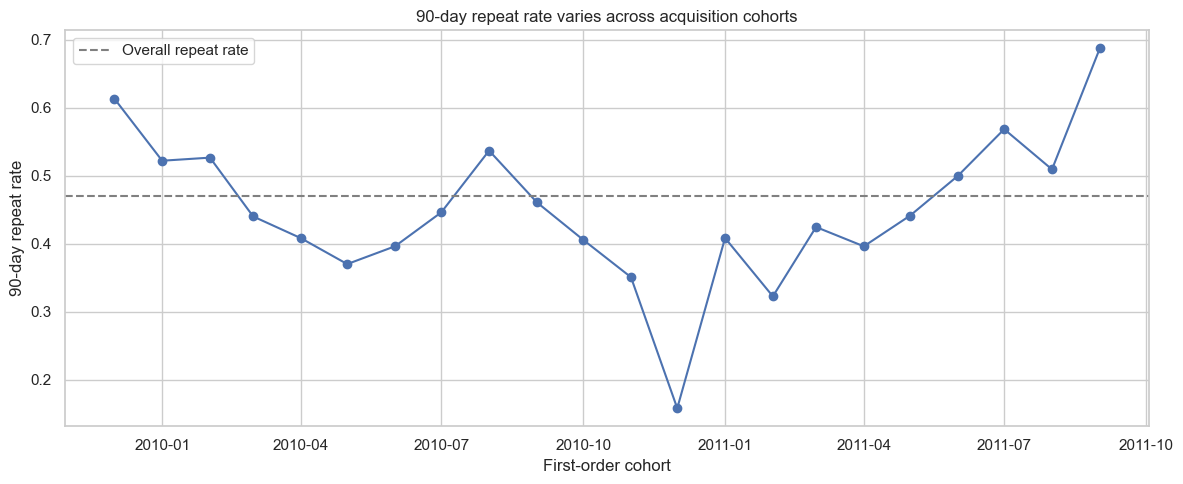

In [31]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    cohort_summary["first_order_cohort"],
    cohort_summary["repeat_rate"],
    marker="o"
)

ax1.axhline(
    repeat_rate,
    color="grey",
    linestyle="--",
    label="Overall repeat rate"
)

ax1.set_ylabel("90-day repeat rate")
ax1.set_xlabel("First-order cohort")
ax1.set_title("90-day repeat rate varies across acquisition cohorts")
ax1.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "repeat_rate_by_cohort.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
cohort_summary[
    [
        "first_order_cohort",
        "customers",
        "repeat_rate",
        "ci_low",
        "ci_high",
    ]
]

,first_order_cohort,customers,repeat_rate,ci_low,ci_high
0,2009-12-01,955,0.613613,0.582334,0.643981
1,2010-01-01,383,0.522193,0.472196,0.571750
2,2010-02-01,374,0.526738,0.476122,0.576810
3,2010-03-01,443,0.440181,0.394665,0.486725
4,2010-04-01,294,0.408163,0.353517,0.465178
5,2010-05-01,254,0.370079,0.313049,0.430980
6,2010-06-01,270,0.396296,0.339801,0.455702
7,2010-07-01,186,0.446237,0.376603,0.518046
8,2010-08-01,162,0.537037,0.460286,0.612073
9,2010-09-01,243,0.460905,0.399327,0.523701


In [33]:
country_summary = segment_repeat_summary(
    customers,
    "first_order_country"
)

country_summary = country_summary[
    country_summary["customers"] >= 100
].sort_values(
    "repeat_rate",
    ascending=False
)

country_summary

,first_order_country,customers,repeat_customers,repeat_rate,ci_low,ci_high
38,United Kingdom,4813,2250,0.467484,0.45342,0.4816


In [34]:
value_cutoff = customers["first_order_value"].quantile(0.99)

non_extreme_customers = customers[
    customers["first_order_value"] <= value_cutoff
]

sensitivity_summary = pd.DataFrame({
    "sample": [
        "All eligible customers",
        "Exclude top 1% first-order values",
    ],
    "customers": [
        len(customers),
        len(non_extreme_customers),
    ],
    "repeat_rate": [
        customers["repeat_within_90d"].mean(),
        non_extreme_customers["repeat_within_90d"].mean(),
    ],
})

sensitivity_summary

,sample,customers,repeat_rate
0,All eligible customers,5281,0.470365
1,Exclude top 1% first-order values,5228,0.467292


## Preliminary findings

1. Among 5,281 eligible identifiable customers, 47.04% placed another
   valid order within 90 days. The 95% Wilson confidence interval was
   45.69% to 48.38%.

2. The observed repeat rate increased monotonically across first-order
   value quintiles, from 35.57% in the lowest-value group to 59.38% in
   the highest-value group. However, this is a predictive association
   and does not demonstrate that increasing first-order spending would
   cause higher retention.

3. Repeat purchasing also increased with first-order product diversity,
   from 40.64% in the lowest-diversity group to 55.60% in the
   highest-diversity group.

4. Repeat rates varied substantially across first-order cohorts. This
   temporal variation motivates chronological model validation rather
   than a random train-test split.

5. Excluding the top 1% of first-order values changed the overall repeat
   rate from 47.04% to 46.73%, suggesting that the aggregate estimate
   was not materially driven by extreme-value orders.

## Limitations

1. Transactions without customer IDs were excluded because they could
   not be linked across time. These transactions differed from identified
   transactions, so the model may not generalise to anonymous customers.

2. The observed relationships are predictive associations rather than
   causal effects.

3. Some cohorts were small and therefore produced wide confidence
   intervals.

4. The dataset includes wholesale customers and administrative transaction
   codes, which require additional robustness checks.

5. Orders occurring shortly after the first order may represent genuine
   repeat purchases, order extensions, or operationally split transactions.